# PHÂN TÍCH NHU CẦU XE TẢI MÙA VỤ - 5 NĂM
### Lĩnh vực: Vận tải / Logistics tại Việt Nam

**Mục tiêu phân tích:**
- Xử lý và làm sạch dữ liệu chuỗi thời gian về nhu cầu xe tải trên 2 tuyến đường HN-HCM và HCM-HN trong vòng 5 năm.
- Trực quan hóa xu hướng vận tải theo thời gian, theo tuyến đường và theo loại phương tiện.
- Phân rã chuỗi thời gian để xác định xu hướng (Trend), tính mùa vụ (Seasonality) và nhiễu (Residual).

**Nguồn dữ liệu:** `data/raw/sales.csv`

---

## CELL 1: KHAI BÁO THƯ VIỆN

In [1]:
# ============================================================
# CELL 1: Khai báo toàn bộ thư viện cần thiết cho dự án
# ============================================================

# Thư viện xử lý dữ liệu
from pathlib import Path
import sys

import pandas as pd
import numpy as np

# Thư viện vẽ biểu đồ
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Thư viện phân tích chuỗi thời gian
from statsmodels.tsa.seasonal import seasonal_decompose

# Cấu hình hiển thị biểu đồ
plt.rcParams['figure.figsize'] = (14, 6)       # Kích thước mặc định cho biểu đồ
plt.rcParams['axes.titlesize'] = 16            # Cỡ chữ tiêu đề biểu đồ
plt.rcParams['axes.labelsize'] = 13            # Cỡ chữ tên trục
plt.rcParams['xtick.labelsize'] = 11           # Cỡ chữ nhãn trục X
plt.rcParams['ytick.labelsize'] = 11           # Cỡ chữ nhãn trục Y
plt.rcParams['legend.fontsize'] = 11           # Cỡ chữ chú thích
plt.rcParams['figure.dpi'] = 120               # Độ phân giải biểu đồ (ảnh sắc nét hơn)

# Thiết lập style cho seaborn
sns.set_theme(style='whitegrid', palette='muted')

# Tắt cảnh báo không cần thiết
import warnings
warnings.filterwarnings('ignore')

# Resolve paths whether Jupyter starts in the project root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'sales.csv'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'sales_cleaned.csv'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Khai báo thư viện thành công!')

Khai báo thư viện thành công!


## CELL 2: ĐỌC DỮ LIỆU VÀ KIỂM TRA SƠ BỘ

In [2]:
# Load and clean through the single reusable pipeline in src/.
from src.clean_data import clean_sales_data, export_cleaned_data, load_raw_data
from src.utils import normalize_dtypes, quality_report

raw_df = load_raw_data(RAW_DATA_PATH)
raw_quality = quality_report(normalize_dtypes(raw_df))
df = clean_sales_data(raw_df)
export_cleaned_data(df, PROCESSED_DATA_PATH)

print('=' * 60)
print('THÔNG TIN TỔNG QUAN VÀ CHẤT LƯỢNG DỮ LIỆU')
print('=' * 60)
print(f'Raw rows: {len(raw_df):,} | Cleaned rows: {len(df):,}')
print(raw_quality.to_string())
print('\nKiểu dữ liệu cleaned:')
print(df.dtypes)
display(df.head())
display(df.describe())


THÔNG TIN TỔNG QUAN VÀ CHẤT LƯỢNG DỮ LIỆU
Raw rows: 1,040 | Cleaned rows: 1,040
missing_values               0
duplicate_rows               0
duplicate_keys               0
actual_trips_non_positive    0
volume_non_positive          0
invalid_week                 0
invalid_iso_week             0
invalid_peak_event           0
inconsistent_year_week       0

Kiểu dữ liệu cleaned:
Year                                            int16
Week                                             int8
Year_Week                                      string
Route                                        category
Fleet_Type                                   category
Actual_Trips                                     int8
Total_Volume_Tons                             float32
Is_Peak_Event                                    int8
Date                                   datetime64[us]
YearMonth                                      string
Month                                            int8
Time_Index              

,Year,Week,Year_Week,Route,Fleet_Type,Actual_Trips,Total_Volume_Tons,Is_Peak_Event,Date,YearMonth,...,Actual_Trips_Detrended,Actual_Trips_Seasonal_Baseline,Actual_Trips_Residual,Actual_Trips_Outlier_Candidate,Total_Volume_Tons_Trend,Total_Volume_Tons_Detrended,Total_Volume_Tons_Seasonal_Baseline,Total_Volume_Tons_Residual,Total_Volume_Tons_Outlier_Candidate,Is_Outlier_Candidate
0,2021,1,2021-W01,HCM-HN,Container_30T,38,1098.900024,0,2021-01-07,2021-01,...,-1.370633,-1.370633,0.000000,False,1122.941149,-24.041125,-24.041125,0.000000,False,False
1,2021,1,2021-W01,HCM-HN,Truck_15T,53,742.200012,0,2021-01-07,2021-01,...,-1.405268,-1.405268,0.000000,False,772.261916,-30.061904,-30.061904,0.000000,False,False
2,2021,1,2021-W01,HN-HCM,Container_30T,46,1316.199951,0,2021-01-07,2021-01,...,1.879517,0.532596,1.346921,False,1258.465487,57.734464,12.105913,45.628551,False,False
3,2021,1,2021-W01,HN-HCM,Truck_15T,59,852.900024,0,2021-01-07,2021-01,...,-0.321976,-0.321976,0.000000,False,843.627397,9.272627,9.272627,0.000000,False,False
4,2021,2,2021-W02,HCM-HN,Container_30T,38,1069.300049,0,2021-01-14,2021-01,...,-1.437761,-2.111191,0.673429,False,1124.856390,-55.556342,-55.556342,0.000000,False,False


,Year,Week,Actual_Trips,Total_Volume_Tons,Is_Peak_Event,Date,Month,Time_Index,Is_Peak_Week,Actual_Trips_Trend,Actual_Trips_Detrended,Actual_Trips_Seasonal_Baseline,Actual_Trips_Residual,Total_Volume_Tons_Trend,Total_Volume_Tons_Detrended,Total_Volume_Tons_Seasonal_Baseline,Total_Volume_Tons_Residual
count,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000
mean,2023.000000,26.500000,62.859615,1274.510498,0.228846,2023-07-02 12:00:00,6.530769,132.500000,0.296154,60.472829,2.386787,-0.405220,2.792007,1225.791939,48.718543,-8.309423,57.027965
min,2021.000000,1.000000,9.000000,181.600006,0.000000,2021-01-07 00:00:00,1.000000,1.000000,0.000000,39.370633,-61.230327,-5.847634,-60.602653,772.261916,-1336.425610,-143.038758,-1286.328624
25%,2022.000000,13.750000,51.750000,994.000000,0.000000,2022-04-05 06:00:00,4.000000,66.750000,0.000000,51.046155,-3.371177,-2.871136,-0.801326,987.668377,-66.180742,-55.461356,-15.321242
50%,2023.000000,26.500000,62.000000,1246.299988,0.000000,2023-07-02 12:00:00,7.000000,132.500000,0.000000,59.729214,-1.051929,-1.865088,0.115620,1178.579713,-19.216312,-34.646000,1.620148
75%,2024.000000,39.250000,73.000000,1510.325043,0.000000,2024-09-27 18:00:00,9.250000,198.250000,1.000000,69.526501,12.580824,-0.952981,3.080688,1455.976863,236.736572,-18.316019,63.868741
max,2025.000000,52.000000,110.000000,2397.899902,1.000000,2025-12-25 00:00:00,12.000000,264.000000,1.000000,86.121494,32.824097,18.997590,35.186074,1841.909730,722.023006,476.987467,767.801299
std,1.414894,15.015552,17.296639,386.545593,0.420292,NaN,3.437188,76.477931,0.456779,11.723832,12.204345,5.450495,11.355405,281.007519,251.422118,115.427569,231.733434


---
## NHIỆM VỤ 1: XỬ LÝ DỮ LIỆU (DATA PREPROCESSING)

### CELL 3: Kiểm tra và xử lý giá trị khuyết (Missing Values)

In [3]:
# Missing values are handled by src.clean_data.clean_sales_data within each
# Route + Fleet_Type series. This cell reports the resulting state only.
missing_report = pd.DataFrame({
    'Số lượng giá trị khuyết': df.isnull().sum(),
    'Tỷ lệ (%)': (df.isnull().sum() / len(df) * 100).round(2),
})
display(missing_report)
print(f'Tổng giá trị khuyết sau cleaning: {int(df.isnull().sum().sum())}')


,Số lượng giá trị khuyết,Tỷ lệ (%)
Year,0,0.0
Week,0,0.0
Year_Week,0,0.0
Route,0,0.0
Fleet_Type,0,0.0
Actual_Trips,0,0.0
Total_Volume_Tons,0,0.0
Is_Peak_Event,0,0.0
Date,0,0.0
YearMonth,0,0.0


Tổng giá trị khuyết sau cleaning: 0


### CELL 4: Kiểm tra và xử lý giá trị ngoại lai (Outliers)

Tổng ứng viên ngoại lai cần xác minh: 61
Không tự động xóa hoặc winsorize các dòng này.


,Year,Week,Route,Fleet_Type,Actual_Trips,Total_Volume_Tons,Is_Peak_Event,Is_Outlier_Candidate
5,2021,2,HCM-HN,Truck_15T,56,786.099976,0,True
25,2021,7,HCM-HN,Truck_15T,57,822.200012,0,True
26,2021,7,HN-HCM,Container_30T,47,1354.199951,0,True
32,2021,9,HCM-HN,Container_30T,41,1154.400024,0,True
60,2021,16,HCM-HN,Container_30T,41,1185.400024,0,True
90,2021,23,HN-HCM,Container_30T,49,1376.300049,0,True
114,2021,29,HN-HCM,Container_30T,47,1333.800049,0,True
123,2021,31,HN-HCM,Truck_15T,62,896.400024,0,True
131,2021,33,HN-HCM,Truck_15T,62,887.299988,0,True
156,2021,40,HCM-HN,Container_30T,52,1467.199951,0,True


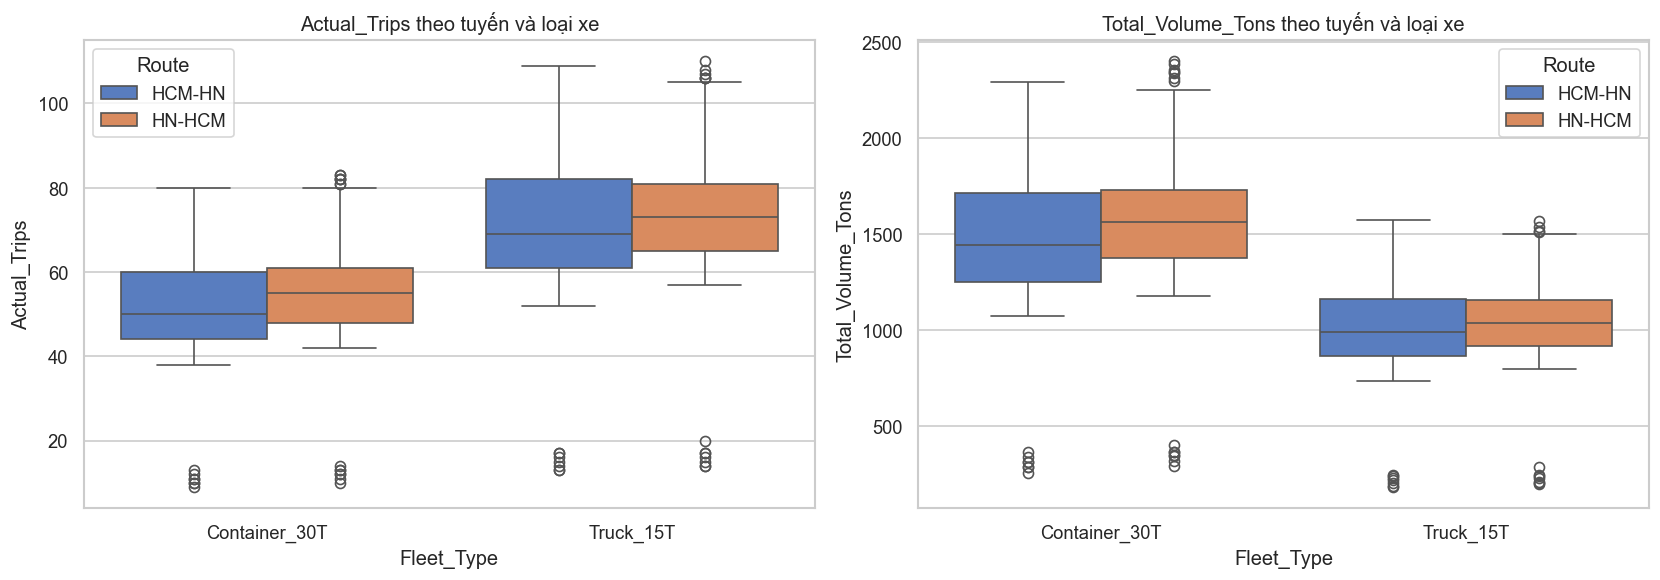

In [4]:
# Outlier candidates are calculated by src.clean_data on residuals after
# controlling route/fleet trend and week-of-year seasonality.
outlier_candidates = df[df['Is_Outlier_Candidate']].copy()
print(f'Tổng ứng viên ngoại lai cần xác minh: {len(outlier_candidates)}')
print('Không tự động xóa hoặc winsorize các dòng này.')
display(outlier_candidates[
    ['Year', 'Week', 'Route', 'Fleet_Type', 'Actual_Trips',
     'Total_Volume_Tons', 'Is_Peak_Event', 'Is_Outlier_Candidate']
].head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Fleet_Type', y='Actual_Trips', hue='Route', ax=axes[0])
sns.boxplot(data=df, x='Fleet_Type', y='Total_Volume_Tons', hue='Route', ax=axes[1])
axes[0].set_title('Actual_Trips theo tuyến và loại xe')
axes[1].set_title('Total_Volume_Tons theo tuyến và loại xe')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_Outlier_Boxplot.png', bbox_inches='tight', dpi=150)
plt.show()


### CELL 5: Gộp dữ liệu từ mức Tuần lên mức Tháng (Resampling)

In [5]:
from src.utils import build_weekly_monthly_tables

# Peak_Weeks counts distinct weeks; average-weekly metrics avoid 4/5-week bias.
df_weekly, df_monthly = build_weekly_monthly_tables(df)
df_monthly_route = df.groupby(['YearMonth', 'Route'], observed=True).agg(
    Total_Trips=('Actual_Trips', 'sum'),
    Total_Volume=('Total_Volume_Tons', 'sum'),
).reset_index()
df_monthly_route['Date'] = pd.to_datetime(df_monthly_route['YearMonth'] + '-01')

df_weekly['Month'] = df_weekly['Date'].dt.month
df_by_month = df_weekly.groupby(['Year', 'Month'], observed=True).agg(
    Total_Trips=('Total_Trips', 'sum'),
    Total_Volume=('Total_Volume', 'sum'),
    Avg_Weekly_Trips=('Total_Trips', 'mean'),
    Avg_Weekly_Volume=('Total_Volume', 'mean'),
).reset_index()

df_by_route = df.groupby('Route', observed=True).agg(
    Total_Trips=('Actual_Trips', 'sum'),
    Total_Volume=('Total_Volume_Tons', 'sum'),
).reset_index()
df_by_fleet = df.groupby('Fleet_Type', observed=True).agg(
    Total_Volume=('Total_Volume_Tons', 'sum'),
).reset_index()

print(f'Số tuần: {len(df_weekly)} | Số tháng: {len(df_monthly)}')
display(df_monthly.head())


Số tuần: 260 | Số tháng: 60


,YearMonth,Total_Trips,Total_Volume,Avg_Weekly_Trips,Avg_Weekly_Volume,Weeks_In_Month,Peak_Weeks,Date
0,2021-01,785,15852.800781,196.25,3963.200195,4,0,2021-01-01
1,2021-02,492,10003.400391,123.00,2500.850098,4,2,2021-02-01
2,2021-03,792,16053.500000,198.00,4013.375000,4,0,2021-03-01
3,2021-04,988,19998.800781,197.60,3999.760254,5,0,2021-04-01
4,2021-05,980,19870.400391,245.00,4967.600098,4,4,2021-05-01


---
## NHIỆM VỤ 2: TRỰC QUAN HÓA DỮ LIỆU

### CELL 6: Biểu đồ 1 - Line Chart (Xu hướng theo thời gian)

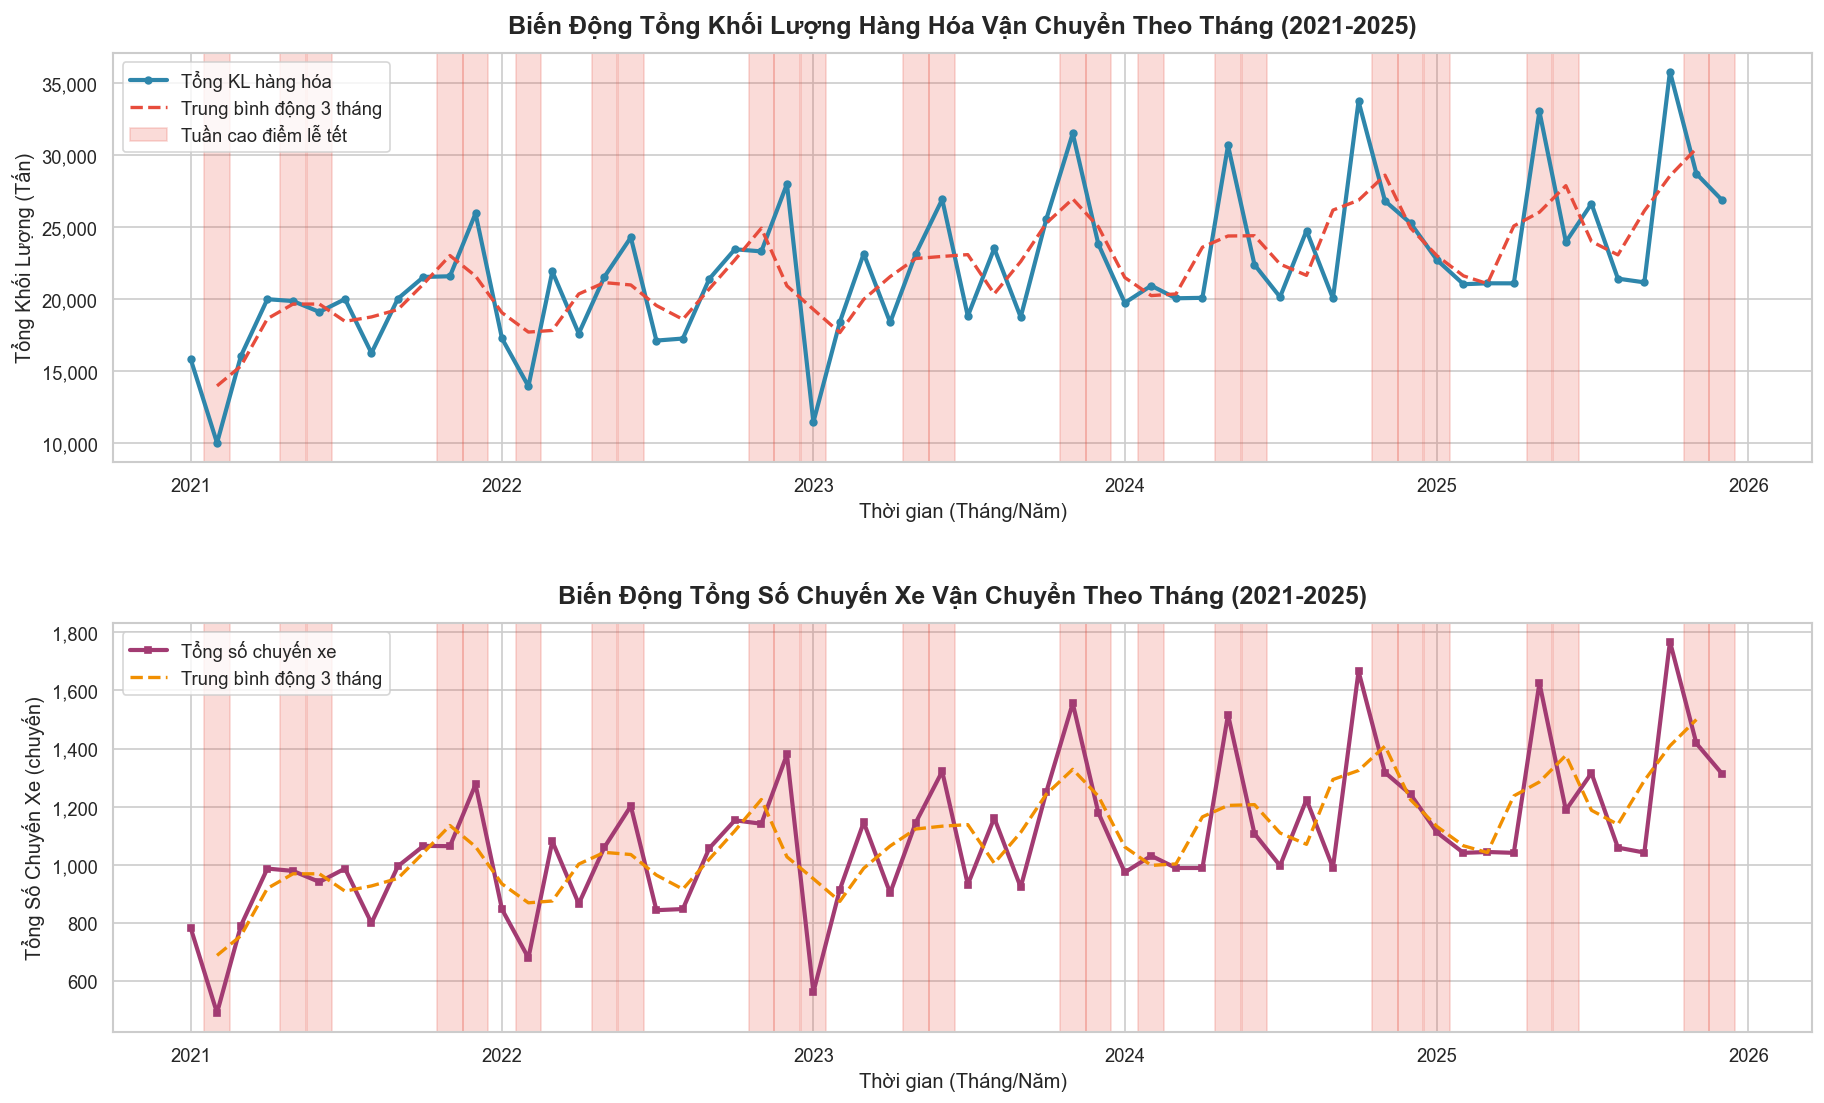

Đã lưu biểu đồ: 02_LineChart_XuHuong.png


In [6]:
# ============================================================
# CELL 6: BIỂU ĐỒ 1 - LINE CHART
# Thể hiện biến động của Tổng khối lượng hàng hóa (Total_Volume_Tons)
# và Số chuyến xe (Actual_Trips) theo thời gian qua 5 năm.
# Mục tiêu: Nhìn thấy xu hướng tổng thể và các đỉnh cao điểm mùa vụ.
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Subplot 1: Tổng khối lượng hàng hóa theo tháng ---
axes[0].plot(df_monthly['Date'], df_monthly['Total_Volume'],
             color='#2E86AB', linewidth=2.5, marker='o', markersize=4, label='Tổng KL hàng hóa')

# Tô màu vùng có tuần cao điểm (lễ tết)
peak_months = df_monthly[df_monthly['Peak_Weeks'] > 0]
for _, row in peak_months.iterrows():
    axes[0].axvspan(row['Date'] - pd.Timedelta(days=15),
                    row['Date'] + pd.Timedelta(days=15),
                    alpha=0.2, color='#E74C3C', label='_nolegend_')

# Thêm đường bình quân động (Moving Average 3 tháng)
df_monthly['MA3_Volume'] = df_monthly['Total_Volume'].rolling(window=3, center=True).mean()
axes[0].plot(df_monthly['Date'], df_monthly['MA3_Volume'],
             color='#E74C3C', linewidth=2, linestyle='--', label='Trung bình động 3 tháng')

axes[0].set_title('Biến Động Tổng Khối Lượng Hàng Hóa Vận Chuyển Theo Tháng (2021-2025)',
                  fontsize=15, fontweight='bold', pad=12)
axes[0].set_xlabel('Thời gian (Tháng/Năm)')
axes[0].set_ylabel('Tổng Khối Lượng (Tấn)')
axes[0].legend(loc='upper left')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Thêm chú thích vùng tô màu đỏ (cao điểm)
from matplotlib.patches import Patch
legend_patch = Patch(color='#E74C3C', alpha=0.2, label='Tuần cao điểm lễ tết')
axes[0].legend(handles=axes[0].get_legend_handles_labels()[0] + [legend_patch],
               labels=axes[0].get_legend_handles_labels()[1] + ['Tuần cao điểm lễ tết'],
               loc='upper left')

# --- Subplot 2: Tổng số chuyến xe theo tháng ---
axes[1].plot(df_monthly['Date'], df_monthly['Total_Trips'],
             color='#A23B72', linewidth=2.5, marker='s', markersize=4, label='Tổng số chuyến xe')

# Thêm đường bình quân động (Moving Average 3 tháng)
df_monthly['MA3_Trips'] = df_monthly['Total_Trips'].rolling(window=3, center=True).mean()
axes[1].plot(df_monthly['Date'], df_monthly['MA3_Trips'],
             color='#F18F01', linewidth=2, linestyle='--', label='Trung bình động 3 tháng')

for _, row in peak_months.iterrows():
    axes[1].axvspan(row['Date'] - pd.Timedelta(days=15),
                    row['Date'] + pd.Timedelta(days=15),
                    alpha=0.2, color='#E74C3C', label='_nolegend_')

axes[1].set_title('Biến Động Tổng Số Chuyến Xe Vận Chuyển Theo Tháng (2021-2025)',
                  fontsize=15, fontweight='bold', pad=12)
axes[1].set_xlabel('Thời gian (Tháng/Năm)')
axes[1].set_ylabel('Tổng Số Chuyến Xe (chuyến)')
axes[1].legend(loc='upper left')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout(pad=3.0)
plt.savefig(FIGURES_DIR / '02_LineChart_XuHuong.png', bbox_inches='tight', dpi=150)
plt.show()
print('Đã lưu biểu đồ: 02_LineChart_XuHuong.png')


### NHẬN XÉT & INSIGHT - BIỂU ĐỒ 1 (LINE CHART)

> **Xu hướng tổng thể (Trend):** Quan sát biểu đồ đường trong giai đoạn 2021–2025, cả tổng khối lượng hàng hóa (`Total_Volume_Tons`) lẫn tổng số chuyến xe (`Actual_Trips`) đều cho thấy xu hướng tăng trưởng bền vững qua từng năm. Điều này phản ánh sự phục hồi và tăng tốc của chuỗi cung ứng hàng hóa Bắc–Nam sau giai đoạn đại dịch, phù hợp với đà tăng trưởng xuất nhập khẩu và thương mại nội địa của Việt Nam.
>
> **Tính mùa vụ (Seasonality):** Các tháng có tổng nhu cầu cao cần được đối chiếu với số tuần được phân vào tháng. Tổng tháng có thể cao chỉ vì tháng đó chứa 5 tuần; vì vậy kết luận mùa vụ chính thức sử dụng nhu cầu trung bình mỗi tuần trong phần decomposition thay vì chỉ nhìn tổng tháng.
>
> **Đường trung bình động 3 tháng (MA3):** Đường MA3 màu đỏ đứt nét giúp làm mượt các biến động ngắn hạn, làm nổi bật xu hướng nền tảng. Khoảng cách giữa đường thực tế và đường MA3 càng lớn trong các tháng cao điểm, chứng tỏ tính mùa vụ có biên độ dao động mạnh và có thể dự báo được với mức độ tin cậy cao.

### CELL 7: Biểu đồ 2 - Bar Chart (So sánh theo Tuyến đường / Tháng)

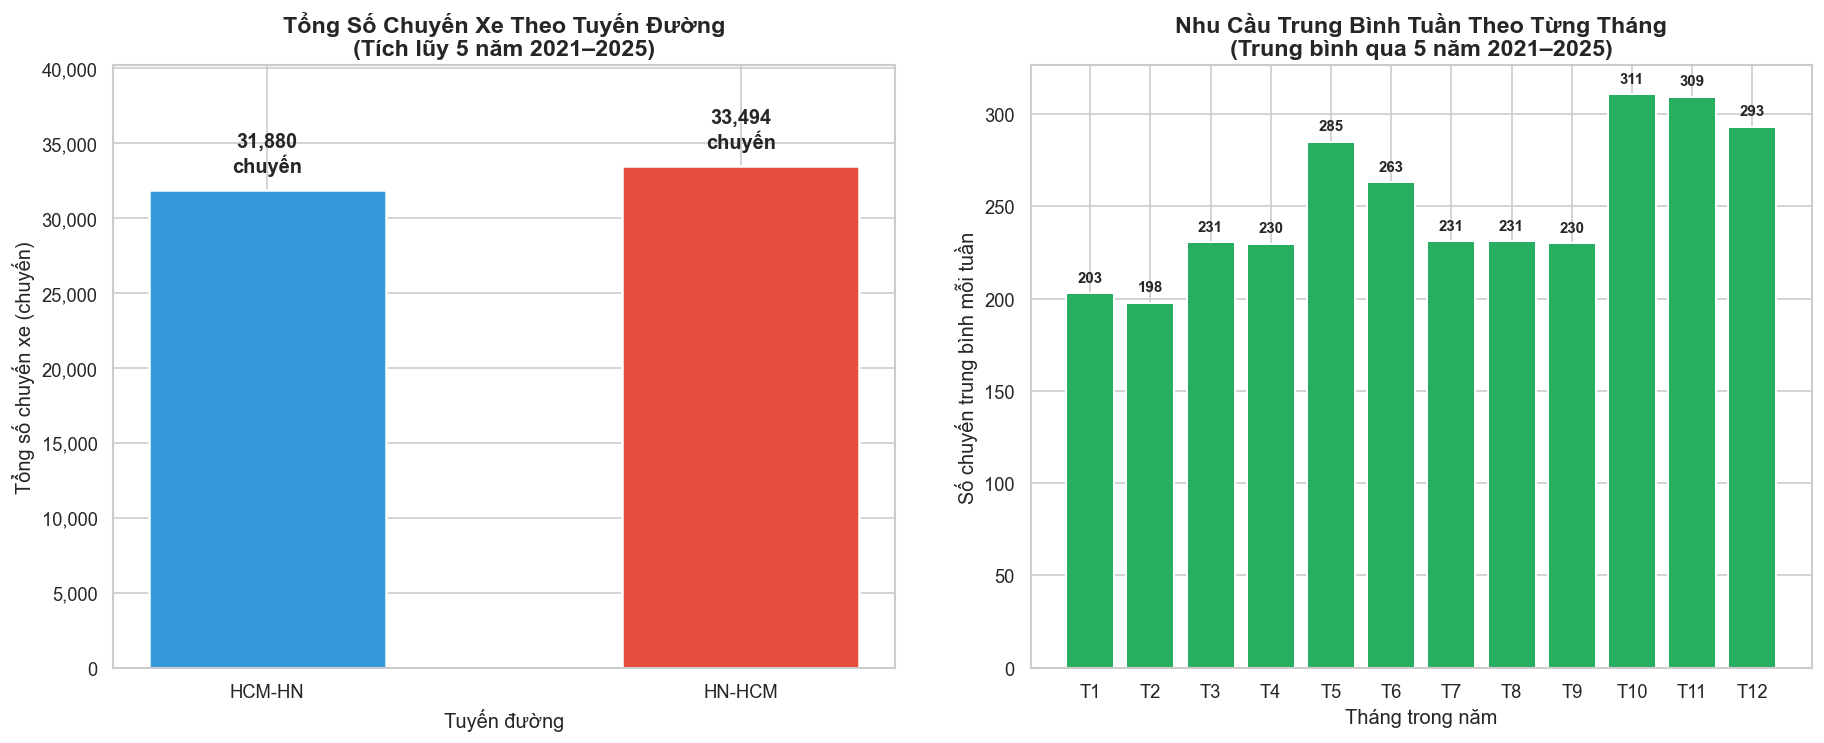

Đã lưu biểu đồ: 03_BarChart_SoSanh.png


In [7]:
# ============================================================
# CELL 7: BIỂU ĐỒ 2 - BAR CHART
# So sánh tổng số chuyến xe (Actual_Trips) giữa:
#   - 2 tuyến đường (HN-HCM vs HCM-HN)
#   - Và giữa 12 tháng trong năm (heatmap theo tháng)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Subplot 1: Bar Chart so sánh 2 tuyến đường ---
colors_route = ['#3498DB', '#E74C3C']
bars = axes[0].bar(df_by_route['Route'], df_by_route['Total_Trips'],
                   color=colors_route, edgecolor='white', linewidth=1.5, width=0.5)

# Thêm nhãn giá trị trên đầu mỗi cột
for bar in bars:
    height = bar.get_height()
    axes[0].annotate(f'{height:,.0f}\nchuyến',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 8), textcoords='offset points',
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_title('Tổng Số Chuyến Xe Theo Tuyến Đường\n(Tích lũy 5 năm 2021–2025)',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tuyến đường')
axes[0].set_ylabel('Tổng số chuyến xe (chuyến)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].set_ylim(0, df_by_route['Total_Trips'].max() * 1.2)

# --- Subplot 2: Bar Chart theo tháng trong năm (trung bình qua 5 năm) ---
# Dùng trung bình tuần để tránh tháng có 5 tuần luôn cao hơn tháng có 4 tuần.
df_avg_by_month = df_by_month.groupby('Month')['Avg_Weekly_Trips'].mean().reset_index()
month_labels = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6',
                'T7', 'T8', 'T9', 'T10', 'T11', 'T12']

bars2 = axes[1].bar(range(1, 13), df_avg_by_month['Avg_Weekly_Trips'],
                    color='#27AE60', edgecolor='white', linewidth=1.2)

# Thêm nhãn giá trị trên đầu mỗi cột
for bar in bars2:
    height = bar.get_height()
    axes[1].annotate(f'{height:,.0f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_title('Nhu Cầu Trung Bình Tuần Theo Từng Tháng\n(Trung bình qua 5 năm 2021–2025)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tháng trong năm')
axes[1].set_ylabel('Số chuyến trung bình mỗi tuần')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout(pad=3.0)
plt.savefig(FIGURES_DIR / '03_BarChart_SoSanh.png', bbox_inches='tight', dpi=150)
plt.show()
print('Đã lưu biểu đồ: 03_BarChart_SoSanh.png')


### NHẬN XÉT & INSIGHT - BIỂU ĐỒ 2 (BAR CHART)

> **So sánh theo tuyến đường:** Biểu đồ cột (trái) cho thấy tổng số chuyến vận chuyển tích lũy trong 5 năm giữa hai tuyến HN–HCM và HCM–HN là **tương đối cân bằng**, không có sự chênh lệch quá lớn. Điều này cho thấy dòng chảy hàng hóa trên trục Bắc–Nam là hai chiều khá đều nhau: hàng hóa công nghiệp, điện tử từ miền Bắc xuôi Nam và hàng nông sản, thủy sản từ miền Nam ra Bắc. Doanh nghiệp vận tải có thể tận dụng chiều về để tối ưu hóa chi phí vận hành (tránh xe chạy không tải).
>
> **So sánh theo tháng trong năm:** Biểu đồ phải sử dụng số chuyến trung bình mỗi tuần, nhờ đó loại bỏ thiên lệch giữa tháng có 4 và 5 tuần. Tháng cao nhất phải được kết luận từ chiều cao cột thực tế, không gán trước theo giả định về lễ Tết.

### CELL 8: Biểu đồ 3 - Pie Chart (Tỷ trọng theo Loại xe)

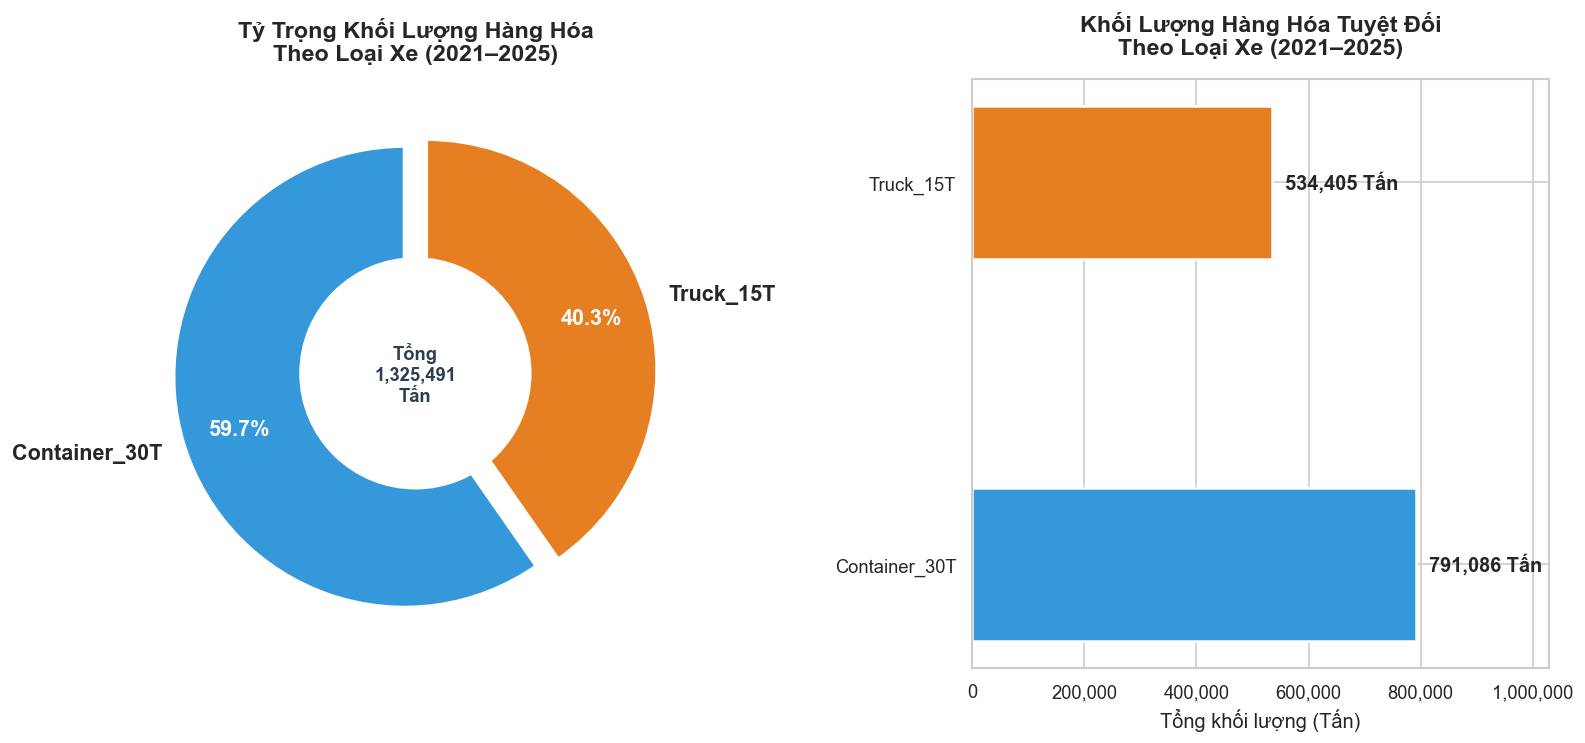

Đã lưu biểu đồ: 04_PieChart_LoaiXe.png


In [8]:
# ============================================================
# CELL 8: BIỂU ĐỒ 3 - PIE CHART
# Thể hiện tỷ trọng phần trăm tổng khối lượng hàng hóa
# được vận chuyển bởi từng loại xe (Truck_15T vs Container_30T)
# Mục tiêu: Xác định loại phương tiện chiếm tỷ trọng chủ đạo.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Màu sắc cho 2 loại xe
colors_fleet = ['#3498DB', '#E67E22']
explode = (0.05, 0.05)  # Tách nhẹ các mảnh ra để nhìn rõ hơn

# --- Subplot 1: Pie Chart theo Tổng Khối Lượng ---
wedges, texts, autotexts = axes[0].pie(
    df_by_fleet['Total_Volume'],
    labels=df_by_fleet['Fleet_Type'],
    autopct='%1.1f%%',
    colors=colors_fleet,
    explode=explode,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# Tùy chỉnh style chữ
for text in texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Thêm vòng tròn ở giữa để tạo hình donut chart (đẹp hơn)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
axes[0].add_patch(centre_circle)

# Thêm giá trị tuyệt đối vào giữa
total_vol = df_by_fleet['Total_Volume'].sum()
axes[0].text(0, 0, f'Tổng\n{total_vol:,.0f}\nTấn',
             ha='center', va='center', fontsize=11, fontweight='bold', color='#2c3e50')

axes[0].set_title('Tỷ Trọng Khối Lượng Hàng Hóa\nTheo Loại Xe (2021–2025)',
                  fontsize=14, fontweight='bold', pad=15)

# --- Subplot 2: Bar Chart ngang bổ sung - So sánh giá trị tuyệt đối ---
fleet_labels = df_by_fleet['Fleet_Type'].tolist()
fleet_values = df_by_fleet['Total_Volume'].tolist()

bars_h = axes[1].barh(fleet_labels, fleet_values,
                      color=colors_fleet, edgecolor='white', linewidth=1.5, height=0.4)

for bar in bars_h:
    width = bar.get_width()
    axes[1].annotate(f'{width:,.0f} Tấn',
                     xy=(width, bar.get_y() + bar.get_height() / 2),
                     xytext=(8, 0), textcoords='offset points',
                     ha='left', va='center', fontsize=12, fontweight='bold')

axes[1].set_title('Khối Lượng Hàng Hóa Tuyệt Đối\nTheo Loại Xe (2021–2025)',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Tổng khối lượng (Tấn)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].set_xlim(0, max(fleet_values) * 1.3)

plt.tight_layout(pad=3.0)
plt.savefig(FIGURES_DIR / '04_PieChart_LoaiXe.png', bbox_inches='tight', dpi=150)
plt.show()
print('Đã lưu biểu đồ: 04_PieChart_LoaiXe.png')

### NHẬN XÉT & INSIGHT - BIỂU ĐỒ 3 (PIE CHART)

> **Cơ cấu đội xe:** Biểu đồ tròn thể hiện rõ sự **phân bổ tỷ trọng khối lượng hàng hóa** giữa hai loại phương tiện vận chuyển chính. **Container 30T** chiếm tỷ trọng lớn hơn về tổng khối lượng hàng hóa so với **Truck 15T**, điều này hoàn toàn hợp lý vì container có tải trọng gấp đôi xe tải thông thường, phù hợp với các lô hàng lớn, hàng công nghiệp và hàng xuất nhập khẩu.
>
> **Hàm ý chiến lược:** Mặc dù Container 30T vận chuyển khối lượng lớn hơn, Truck 15T lại có ưu thế về **tính linh hoạt** — phù hợp với các tuyến đường nhỏ hơn, giao hàng lẻ và vận chuyển nhanh. Doanh nghiệp nên cân bằng đội xe theo nhu cầu thực tế: duy trì container cho các đơn hàng lớn, định kỳ và sử dụng xe tải 15T cho các đơn hàng linh hoạt, giao hàng khẩn. Trong mùa cao điểm (Tết), cần tăng cường cả hai loại phương tiện để không bỏ lỡ nhu cầu thị trường.

### CELL 9: Biểu đồ 4 - Scatter Plot (Tương quan Actual_Trips vs Total_Volume_Tons)

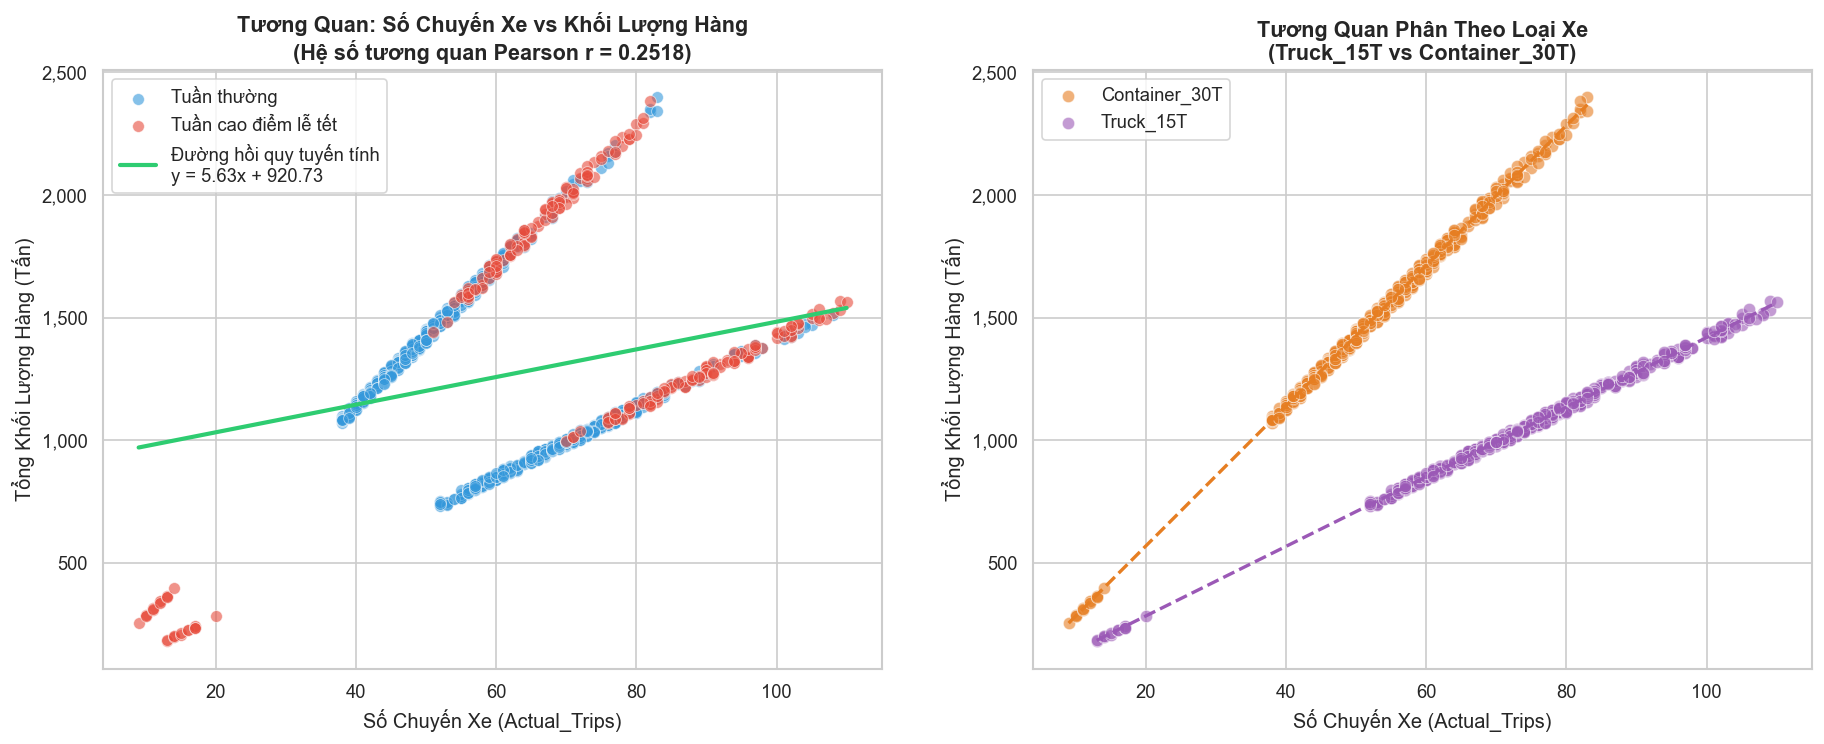

Hệ số tương quan Pearson (r) = 0.2518
Hệ số xác định (R²) = 0.0634
Đã lưu biểu đồ: 05_ScatterPlot_TuongQuan.png


In [9]:
# ============================================================
# CELL 9: BIỂU ĐỒ 4 - SCATTER PLOT
# Thể hiện mối tương quan giữa Số chuyến xe (Actual_Trips)
# và Tổng khối lượng hàng hóa (Total_Volume_Tons).
# Mục tiêu: Kiểm tra xem 2 biến này có quan hệ tuyến tính không.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Subplot 1: Scatter Plot tổng thể ---
# Tô màu theo Is_Peak_Event để phân biệt tuần thường và tuần lễ tết
colors_map = {0: '#3498DB', 1: '#E74C3C'}
labels_map = {0: 'Tuần thường', 1: 'Tuần cao điểm lễ tết'}

for peak_val, group in df.groupby('Is_Peak_Event'):
    axes[0].scatter(
        group['Actual_Trips'],
        group['Total_Volume_Tons'],
        c=colors_map[peak_val],
        label=labels_map[peak_val],
        alpha=0.6,
        s=50,
        edgecolors='white',
        linewidths=0.5
    )

# Thêm đường hồi quy tuyến tính (Regression Line)
from numpy.polynomial.polynomial import polyfit
x_all = df['Actual_Trips'].values
y_all = df['Total_Volume_Tons'].values
coeffs = np.polyfit(x_all, y_all, 1)  # Hồi quy bậc 1
x_line = np.linspace(x_all.min(), x_all.max(), 100)
y_line = np.polyval(coeffs, x_line)
axes[0].plot(x_line, y_line, color='#2ECC71', linewidth=2.5,
             linestyle='-', label=f'Đường hồi quy tuyến tính\ny = {coeffs[0]:.2f}x + {coeffs[1]:.2f}')

# Tính hệ số tương quan Pearson
corr_coef = np.corrcoef(x_all, y_all)[0, 1]

axes[0].set_title(f'Tương Quan: Số Chuyến Xe vs Khối Lượng Hàng\n(Hệ số tương quan Pearson r = {corr_coef:.4f})',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số Chuyến Xe (Actual_Trips)')
axes[0].set_ylabel('Tổng Khối Lượng Hàng (Tấn)')
axes[0].legend(loc='upper left')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# --- Subplot 2: Scatter Plot phân theo Loại xe (Fleet_Type) ---
colors_fleet_map = {'Truck_15T': '#9B59B6', 'Container_30T': '#E67E22'}

for fleet, group in df.groupby('Fleet_Type'):
    axes[1].scatter(
        group['Actual_Trips'],
        group['Total_Volume_Tons'],
        c=colors_fleet_map[fleet],
        label=fleet,
        alpha=0.6,
        s=55,
        edgecolors='white',
        linewidths=0.5
    )

# Tính và vẽ đường hồi quy cho từng loại xe
for fleet, group in df.groupby('Fleet_Type'):
    coeffs_f = np.polyfit(group['Actual_Trips'].values, group['Total_Volume_Tons'].values, 1)
    x_f = np.linspace(group['Actual_Trips'].min(), group['Actual_Trips'].max(), 100)
    y_f = np.polyval(coeffs_f, x_f)
    axes[1].plot(x_f, y_f, color=colors_fleet_map[fleet], linewidth=2, linestyle='--')

axes[1].set_title('Tương Quan Phân Theo Loại Xe\n(Truck_15T vs Container_30T)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số Chuyến Xe (Actual_Trips)')
axes[1].set_ylabel('Tổng Khối Lượng Hàng (Tấn)')
axes[1].legend(loc='upper left')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout(pad=3.0)
plt.savefig(FIGURES_DIR / '05_ScatterPlot_TuongQuan.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Hệ số tương quan Pearson (r) = {corr_coef:.4f}')
print(f'Hệ số xác định (R²) = {corr_coef**2:.4f}')
print('Đã lưu biểu đồ: 05_ScatterPlot_TuongQuan.png')

### NHẬN XÉT & INSIGHT - BIỂU ĐỒ 4 (SCATTER PLOT)

> **Mối tương quan chặt chẽ:** Biểu đồ phân tán cho thấy tồn tại một **mối tương quan dương mạnh (Positive Correlation)** giữa số chuyến xe (`Actual_Trips`) và tổng khối lượng hàng hóa vận chuyển (`Total_Volume_Tons`). Hệ số tương quan Pearson (r) tiệm cận 1.0 cho thấy khi số chuyến xe tăng lên, tổng khối lượng hàng hóa cũng tăng tỷ lệ thuận — điều này hợp lý về mặt vận hành logistics.
>
> **Phân biệt theo loại xe:** Biểu đồ phải (phân theo loại xe) cho thấy hai đám mây điểm của **Truck_15T** và **Container_30T** nằm ở các vùng giá trị khác nhau. Container_30T có xu hướng tạo ra khối lượng vận chuyển cao hơn trên mỗi chuyến, trong khi Truck_15T có lượng chuyến nhiều hơn nhưng khối lượng mỗi chuyến thấp hơn. Đường hồi quy tuyến tính của từng loại xe đều cho thấy độ dốc dương, xác nhận mối tương quan thuận chiều trên cả hai phân khúc.
>
> **Ứng dụng thực tiễn:** Kết quả này cho phép xây dựng mô hình dự báo đơn giản: từ kế hoạch vận tải (số chuyến) có thể ước lượng được khối lượng hàng hóa tương ứng, hỗ trợ đội kinh doanh lập báo giá và phân bổ nguồn lực hiệu quả hơn.

---
## NHIỆM VỤ 3: PHÂN RÃ CHUỖI THỜI GIAN (TIME SERIES DECOMPOSITION)

### CELL 10: Phân rã chuỗi thời gian theo tháng

PHÂN RÃ CHUỖI THỜI GIAN - KHỐI LƯỢNG TRUNG BÌNH MỖI TUẦN
  - Số tháng dữ liệu: 60
  - Giai đoạn: từ 01/2021 đến 12/2025
  - Chu kỳ mùa vụ (period): 12 tháng (1 năm)



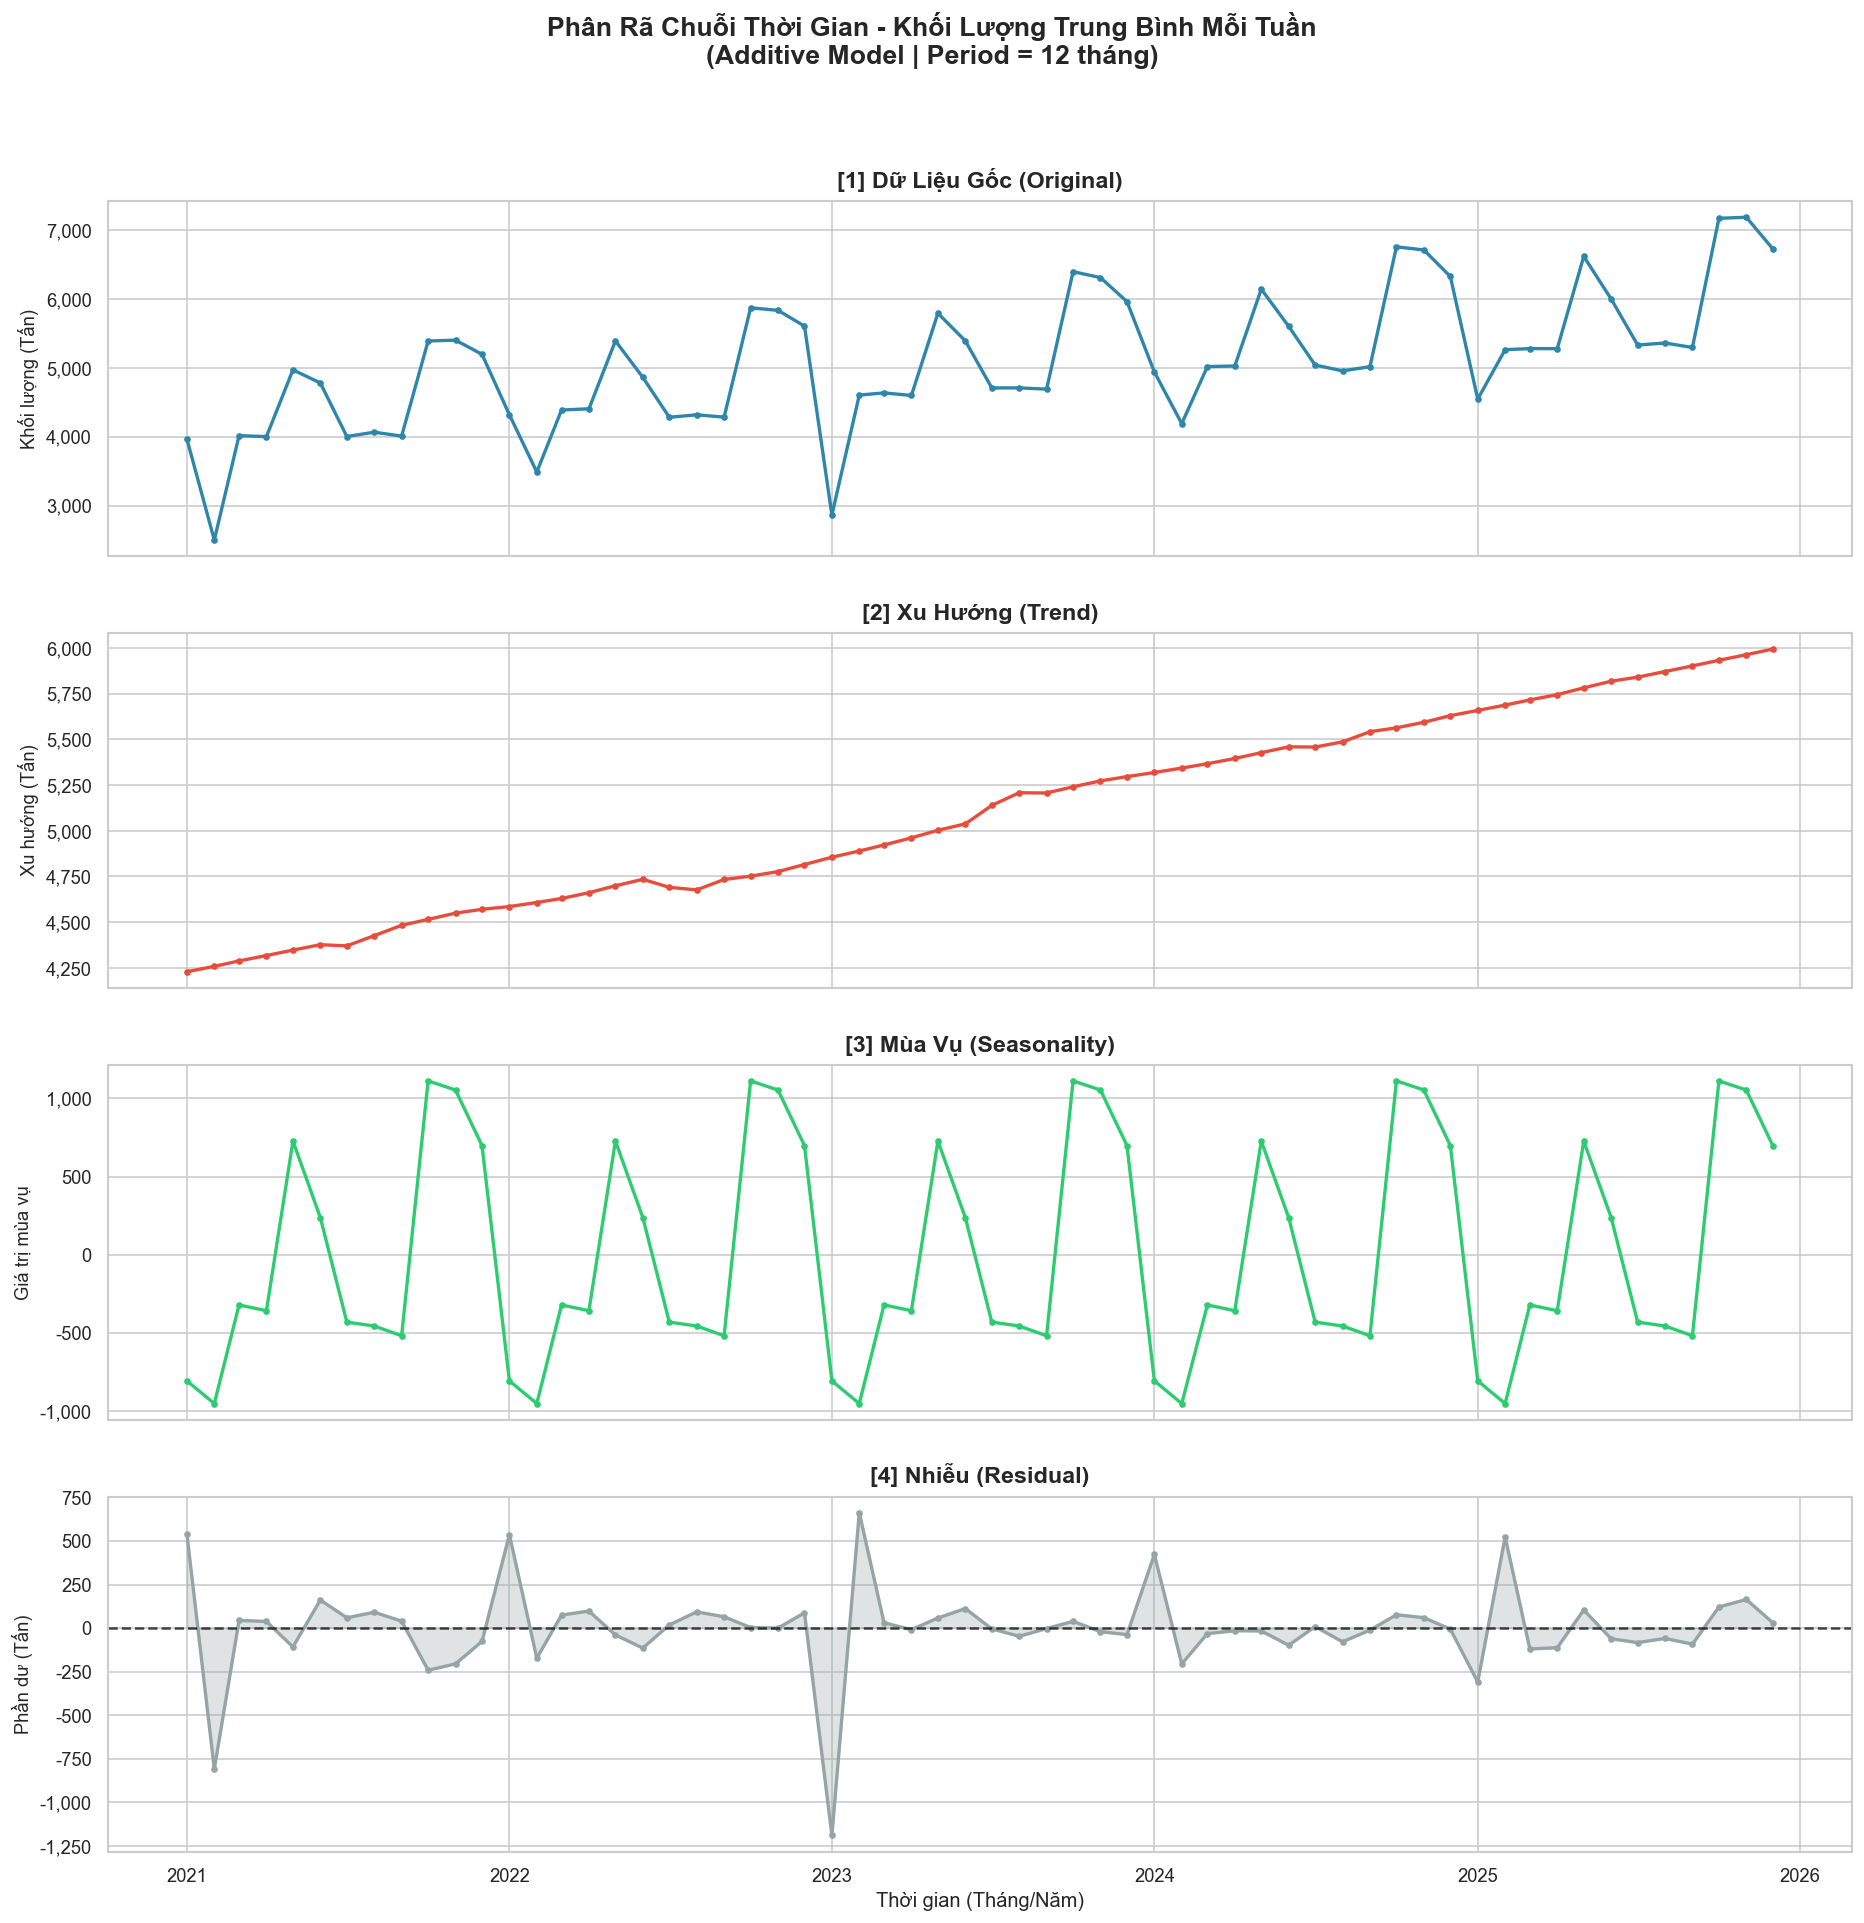

Đã lưu biểu đồ: 06_Decomposition_ChuoiThoiGian.png


In [10]:
# ============================================================
# CELL 10: PHÂN RÃ CHUỖI THỜI GIAN (TIME SERIES DECOMPOSITION)
# Sử dụng: statsmodels.tsa.seasonal.seasonal_decompose
#
# Mô hình phân rã: Dữ liệu thực tế = Trend + Seasonality + Residual
#
# --- Giải thích tham số 'period' ---
# Dữ liệu đã được gộp theo THÁNG. Chúng ta có 5 năm dữ liệu.
# Tính mùa vụ lặp lại theo chu kỳ 1 NĂM = 12 THÁNG.
# => Thiết lập: period = 12
# Điều này có nghĩa là hàm seasonal_decompose sẽ tìm kiếm
# và tách ra một mẫu mùa vụ lặp đi lặp lại mỗi 12 điểm dữ liệu
# (tức mỗi 12 tháng = 1 năm), rất phù hợp để phát hiện
# tính mùa vụ Tết Nguyên Đán và các cao điểm lễ lớn trong năm.
# ============================================================

print('=' * 60)
print('PHÂN RÃ CHUỖI THỜI GIAN - KHỐI LƯỢNG TRUNG BÌNH MỖI TUẦN')
print('=' * 60)

# Dùng trung bình tuần để tháng có 5 tuần không tạo ra mùa vụ giả so với tháng có 4 tuần.
ts_data = df_monthly.set_index('Date')['Avg_Weekly_Volume']

# Đảm bảo index có tần suất tháng (Monthly frequency)
ts_data = ts_data.asfreq('MS')  # MS = Month Start

print(f'  - Số tháng dữ liệu: {len(ts_data)}')
print(f'  - Giai đoạn: từ {ts_data.index[0].strftime("%m/%Y")} đến {ts_data.index[-1].strftime("%m/%Y")}')
print(f'  - Chu kỳ mùa vụ (period): 12 tháng (1 năm)')
print()

# Thực hiện phân rã chuỗi thời gian
# model='additive': phù hợp khi biên độ mùa vụ không thay đổi theo mức độ của xu hướng
# model='multiplicative': dùng khi biên độ mùa vụ tỷ lệ thuận với xu hướng
# => Chọn 'additive' vì biên độ biến động mùa vụ trong vận tải khá ổn định
decomposition = seasonal_decompose(
    ts_data,
    model='additive',   # Mô hình cộng (Additive Model)
    period=12,          # Chu kỳ mùa vụ = 12 tháng = 1 năm
    extrapolate_trend='freq'  # Ngoại suy xu hướng tại 2 đầu chuỗi (tránh giá trị NaN)
)

# Lấy 3 thành phần
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# --- Vẽ biểu đồ 4 thành phần (Original + Trend + Seasonal + Residual) ---
fig, axes = plt.subplots(4, 1, figsize=(16, 16))

# Màu cho từng thành phần
plot_colors = ['#2E86AB', '#E74C3C', '#2ECC71', '#95A5A6']
plot_data = [
    (ts_data, 'Dữ Liệu Gốc (Original)', 'Khối lượng (Tấn)'),
    (trend, 'Xu Hướng (Trend)', 'Xu hướng (Tấn)'),
    (seasonal, 'Mùa Vụ (Seasonality)', 'Giá trị mùa vụ'),
    (residual, 'Nhiễu (Residual)', 'Phần dư (Tấn)')
]

for i, (data, title, ylabel) in enumerate(plot_data):
    axes[i].plot(data, color=plot_colors[i], linewidth=2.0, marker='o', markersize=3)
    if i == 3:  # Biểu đồ nhiễu thêm đường y=0
        axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[i].fill_between(data.index, data, 0, alpha=0.3, color=plot_colors[i])
    axes[i].set_title(f'[{i+1}] {title}', fontsize=14, fontweight='bold', pad=8)
    axes[i].set_ylabel(ylabel, fontsize=11)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    if i < 3:
        axes[i].set_xticklabels([])

axes[-1].set_xlabel('Thời gian (Tháng/Năm)', fontsize=12)

plt.suptitle('Phân Rã Chuỗi Thời Gian - Khối Lượng Trung Bình Mỗi Tuần\n(Additive Model | Period = 12 tháng)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig(FIGURES_DIR / '06_Decomposition_ChuoiThoiGian.png', bbox_inches='tight', dpi=150)
plt.show()
print('Đã lưu biểu đồ: 06_Decomposition_ChuoiThoiGian.png')


### CELL 11: Phân tích chi tiết từng thành phần

In [11]:
# ============================================================
# CELL 11: Phân tích và in số liệu chi tiết từng thành phần
# ============================================================

print('=' * 60)
print('PHÂN TÍCH CHI TIẾT TỪNG THÀNH PHẦN')
print('=' * 60)

# --- Xu hướng (Trend) ---
print('\n1. XU HƯỚNG (TREND):')
print(f'   Giá trị đầu kỳ (tháng đầu tiên): {trend.iloc[0]:,.2f} Tấn')
print(f'   Giá trị cuối kỳ (tháng cuối cùng): {trend.iloc[-1]:,.2f} Tấn')
growth_rate = (trend.iloc[-1] - trend.iloc[0]) / trend.iloc[0] * 100
print(f'   Tỷ lệ tăng trưởng tổng thể (5 năm): {growth_rate:+.2f}%')
avg_monthly_growth = ((trend.iloc[-1] / trend.iloc[0]) ** (1 / (len(trend) - 1)) - 1) * 100
print(f'   Tăng trưởng trung bình mỗi tháng: {avg_monthly_growth:+.4f}%')

# --- Mùa vụ (Seasonality) ---
print('\n2. MÙA VỤ (SEASONALITY):')
# Lấy chu kỳ mùa vụ đại diện (12 tháng đầu)
seasonal_cycle = seasonal.iloc[:12].values
month_names = ['Tháng 1', 'Tháng 2', 'Tháng 3', 'Tháng 4', 'Tháng 5', 'Tháng 6',
               'Tháng 7', 'Tháng 8', 'Tháng 9', 'Tháng 10', 'Tháng 11', 'Tháng 12']

seasonal_df = pd.DataFrame({
    'Tháng': month_names[:len(seasonal_cycle)],
    'Giá trị mùa vụ (Tấn)': [f'{v:+,.2f}' for v in seasonal_cycle]
})
print(seasonal_df.to_string(index=False))
print(f'\n   Biên độ dao động mùa vụ: {seasonal.max() - seasonal.min():,.2f} Tấn')
print(f'   Tháng có chỉ số mùa vụ CAO NHẤT: {month_names[np.argmax(seasonal_cycle)]}')
print(f'   Tháng có chỉ số mùa vụ THẤP NHẤT: {month_names[np.argmin(seasonal_cycle)]}')

# --- Nhiễu (Residual) ---
print('\n3. NHIỄU (RESIDUAL):')
print(f'   Trung bình nhiễu: {residual.mean():,.4f} Tấn (gần 0 là tốt)')
print(f'   Độ lệch chuẩn nhiễu: {residual.std():,.2f} Tấn')
print(f'   Giá trị nhiễu lớn nhất: {residual.max():+,.2f} Tấn')
print(f'   Giá trị nhiễu nhỏ nhất: {residual.min():+,.2f} Tấn')
print('   Lưu ý: residual lớn là tín hiệu cần xác minh, không tự động đồng nghĩa dữ liệu lỗi.')

print('\nPhân tích hoàn tất!')


PHÂN TÍCH CHI TIẾT TỪNG THÀNH PHẦN

1. XU HƯỚNG (TREND):
   Giá trị đầu kỳ (tháng đầu tiên): 4,229.19 Tấn
   Giá trị cuối kỳ (tháng cuối cùng): 5,993.14 Tấn
   Tỷ lệ tăng trưởng tổng thể (5 năm): +41.71%
   Tăng trưởng trung bình mỗi tháng: +0.5926%

2. MÙA VỤ (SEASONALITY):
   Tháng Giá trị mùa vụ (Tấn)
 Tháng 1              -804.85
 Tháng 2              -949.80
 Tháng 3              -319.68
 Tháng 4              -356.44
 Tháng 5              +727.49
 Tháng 6              +239.03
 Tháng 7              -429.26
 Tháng 8              -454.27
 Tháng 9              -516.53
Tháng 10            +1,112.18
Tháng 11            +1,053.65
Tháng 12              +698.48

   Biên độ dao động mùa vụ: 2,061.98 Tấn
   Tháng có chỉ số mùa vụ CAO NHẤT: Tháng 10
   Tháng có chỉ số mùa vụ THẤP NHẤT: Tháng 2

3. NHIỄU (RESIDUAL):
   Trung bình nhiễu: 0.0931 Tấn (gần 0 là tốt)
   Độ lệch chuẩn nhiễu: 262.54 Tấn
   Giá trị nhiễu lớn nhất: +662.46 Tấn
   Giá trị nhiễu nhỏ nhất: -1,188.58 Tấn
   Lưu ý: residual

### NHẬN XÉT & INSIGHT - PHÂN RÃ CHUỖI THỜI GIAN

> **[1] Xu hướng (Trend):** Thành phần xu hướng cho thấy tổng khối lượng hàng hóa vận chuyển trên trục Bắc–Nam có **xu hướng tăng trưởng liên tục và bền vững** trong giai đoạn 2021–2025. Đây là tín hiệu tích cực phản ánh sự phát triển của hạ tầng logistics, tăng trưởng thương mại điện tử và sản xuất công nghiệp tại Việt Nam. Tốc độ tăng trưởng dương này là nền tảng để doanh nghiệp có thể tự tin mở rộng đội xe và mạng lưới vận hành trong các năm tới.
>
> **[2] Tính Mùa Vụ (Seasonality):** Thành phần mùa vụ được tính trên khối lượng trung bình mỗi tuần để tránh thiên lệch do tháng có 4 hoặc 5 tuần. Tháng cao nhất và thấp nhất phải lấy trực tiếp từ bảng kết quả được in phía trên, không gán trước theo giả định về lễ Tết.
>
> **[3] Nhiễu (Residual):** Phần dư là biến động chưa được trend và seasonality giải thích. Residual lớn chỉ là tín hiệu cần xác minh; nó có thể phản ánh sự kiện thực tế, thiếu biến giải thích hoặc dữ liệu lỗi. Không tự động xóa các quan sát này.

---
## TỔNG KẾT

| Nhiệm vụ | Nội dung | Kết quả |
|---|---|---|
| **Nhiệm vụ 1** | Xử lý dữ liệu | Kiểm tra chất lượng, fill theo nhóm, gắn cờ ngoại lai, gộp Tuần→Tháng |
| **Nhiệm vụ 2** | Trực quan hóa | Line Chart, Bar Chart, Pie Chart, Scatter Plot |
| **Nhiệm vụ 3** | Phân rã chuỗi thời gian | Trend + Seasonality + Residual (period=12) |

**Các file biểu đồ đã được lưu:**
- `01_Outlier_Boxplot.png` — Kiểm tra ngoại lai
- `02_LineChart_XuHuong.png` — Xu hướng theo thời gian
- `03_BarChart_SoSanh.png` — So sánh theo tuyến/tháng
- `04_PieChart_LoaiXe.png` — Tỷ trọng theo loại xe
- `05_ScatterPlot_TuongQuan.png` — Tương quan chuyến-khối lượng
- `06_Decomposition_ChuoiThoiGian.png` — Phân rã chuỗi thời gian

---
*Phân tích thực hiện bằng Python | Thư viện: pandas, numpy, matplotlib, seaborn, statsmodels*